# Enterprise Human Capital Misallocation & Performance Audit
**Author:** Alain Eyong Eyong Eneke  

### Executive Summary
This project acts as an **Executive Financial & Human Capital Audit** analyzing direct compensation ($6.87M USD total payroll spend) against performance output, pay grade architecture, age dynamics, and employee tenure across 100 employee records.

#### Key Audit & Operational Findings:
1. **Low-Performance Capital Drain (LPCD):** **$2.80M USD (40.7% of total payroll)** is allocated to underperforming staff (rating 1–2).
2. **Tenure Performance Decay:** Employees with **10+ years of tenure** yield the lowest average performance rating (**2.53** vs. **3.06** for new hires under 3 years), despite earning higher average compensation ($73.9k vs. $66.1k).
3. **Broken Pay-for-Performance:** Statistically zero correlation ($r = 0.0673$) between total compensation and performance ratings.
4. **Pay Grade Overlap:** Base salaries across Grades A–D span $30k–$98k across all bands without enforced midpoints.
5. **Gender Pay Disparity:** Female staff at Branch Offices earn an average of **$62,426** vs. **$70,754** for male staff ($8,328 gap).

In [78]:
# Setup & Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual formatting for notebook
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print(" Environment configured successfully.")

 Environment configured successfully.


## 1. Data Ingestion & Preprocessing
In this step, we load the raw HR dataset, standardize numeric values, handle missing optional data, and compute exact employee tenure as of October 2026.

In [79]:
# Load dataset
file_path = r"E:\SUPERSTORE_DASHBOARD\Executive Capital Allocation & Workforce Performance Audit\HR Dataset.xlsx"
df = pd.read_excel(file_path)

# Standardize financial & performance fields
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce").fillna(0)
df["Bonus/Allowances"] = pd.to_numeric(df["Bonus/Allowances"], errors="coerce").fillna(0)
df["Total_Compensation"] = df["Salary"] + df["Bonus/Allowances"]
df["Leave Taken"] = pd.to_numeric(df["Leave Taken"], errors="coerce").fillna(0)
df["Performance Rating"] = pd.to_numeric(df["Performance Rating"], errors="coerce").fillna(0)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Feature Engineering: Date of Hire -> Tenure Years
df["Date of Hire"] = pd.to_datetime(df["Date of Hire"], errors="coerce")
analysis_date = pd.to_datetime("2026-10-09")
df["Tenure_Years"] = np.round((analysis_date - df["Date of Hire"]).dt.days / 365.25, 2)

# Categorical Bins & Indicators
df["Has_Training"] = df["Training Programs Attended"].notnull().astype(int)
df["Has_Certification"] = df["Certifications"].notnull().astype(int)
df["Tenure_Group"] = pd.cut(df["Tenure_Years"], bins=[0, 3, 6, 10, 25], labels=["0-3 yrs", "3-6 yrs", "6-10 yrs", "10+ yrs"])

print(f"Data shape: {df.shape}")
df[["Employee ID", "Full Name", "Age", "Age range", "Date of Hire", "Tenure_Years", "Total_Compensation"]].head()

Data shape: (100, 26)


,Employee ID,Full Name,Age,Age range,Date of Hire,Tenure_Years,Total_Compensation
0,10001,Lori Nguyen,25,18-25,2019-03-15,7.57,55163
1,10002,Gary Garcia,27,26-35,2022-12-20,3.80,92115
2,10003,Jeremy Nguyen,34,26-35,2022-08-10,4.16,59212
3,10004,Kimberly Jones,41,36-45,2024-09-03,2.10,65688
4,10005,Anthony Gates,56,56 <,2019-03-14,7.57,54549


## 2. HR Operational KPIs
We calculate core operational metrics used in standard HR reporting dashboards.

In [80]:
total_headcount = len(df)
total_payroll = df["Total_Compensation"].sum()
avg_salary = df["Salary"].mean()
avg_tenure = df["Tenure_Years"].mean()
avg_performance = df["Performance Rating"].mean()

# KPI 1: Total Direct Cash Compensation
tcc_val = total_payroll

# KPI 2: Overall Compa-Ratio (Actual Salary vs Target Average Baseline)
target_salary_midpoint = df["Salary"].median()
compa_ratio_avg = (df["Salary"].mean() / target_salary_midpoint)

# KPI 3: Performance-to-Pay Efficiency (Salary per Performance Point)
p2p_efficiency = df["Total_Compensation"].mean() / avg_performance

# KPI 4: Absenteeism Rate (% of 220 Standard Annual Working Days)
total_leave_days = df["Leave Taken"].sum()
absenteeism_rate = (total_leave_days / (total_headcount * 220)) * 100

# KPI 5: Training Coverage Rate
training_coverage_pct = (df["Has_Training"].sum() / total_headcount) * 100

# KPI 6: Certification Upskilling Rate
certification_rate_pct = (df["Has_Certification"].sum() / total_headcount) * 100

# KPI 7: Contingent Workforce Ratio (Contract + Part-Time vs Total)
contingent_count = len(df[df["Employment Status"].isin(["Contract", "Part-Time"])])
contingent_ratio_pct = (contingent_count / total_headcount) * 100

# KPI 8: High Performer Share (Rating 4 or 5)
high_performers_count = len(df[df["Performance Rating"] >= 4])
high_performer_pct = (high_performers_count / total_headcount) * 100

# KPI 9: Insurance Benefits Adoption Rate
insured_count = len(df[df["Insurance Details"].notnull()])
insurance_adoption_pct = (insured_count / total_headcount) * 100

# Display Operational KPI Summary Table
kpi_table = pd.DataFrame({
    "HR Operational KPI": [
        "1. Total Headcount",
        "2. Total Cash Compensation (TCC)",
        "3. Average Compa-Ratio (vs Median Midpoint)",
        "4. Cost per Performance Point",
        "5. Overall Absenteeism Rate",
        "6. Training Participation Rate",
        "7. Certification Rate",
        "8. Contingent Workforce Ratio",
        "9. High Performer Share (Rating 4-5)",
        "10. Benefits & Insurance Adoption Rate"
    ],
    "Value": [
        f"{total_headcount} Employees",
        f"${tcc_val:,.2f}",
        f"{compa_ratio_avg:.2f}",
        f"${p2p_efficiency:,.2f} / Point",
        f"{absenteeism_rate:.2f}%",
        f"{training_coverage_pct:.1f}%",
        f"{certification_rate_pct:.1f}%",
        f"{contingent_ratio_pct:.1f}%",
        f"{high_performer_pct:.1f}%",
        f"{insurance_adoption_pct:.1f}%"
    ]
})

kpi_table

,HR Operational KPI,Value
0,1. Total Headcount,100 Employees
1,2. Total Cash Compensation (TCC),"$6,866,804.00"
2,3. Average Compa-Ratio (vs Median Midpoint),1.05
3,4. Cost per Performance Point,"$23,678.63 / Point"
4,5. Overall Absenteeism Rate,4.77%
5,6. Training Participation Rate,61.0%
6,7. Certification Rate,63.0%
7,8. Contingent Workforce Ratio,59.0%
8,9. High Performer Share (Rating 4-5),35.0%
9,10. Benefits & Insurance Adoption Rate,68.0%


## 3. Executive C-Suite Strategic KPIs (12 Strategic Metrics)
We compute 12 strategic financial, demographic, tenure, and capital efficiency metrics for C-Suite leadership.

In [81]:
total_payroll = df["Total_Compensation"].sum()
median_comp = df["Total_Compensation"].median()

# KPI 1: Low-Performance Capital Drain (LPCD)
low_perf_df = df[df["Performance Rating"] <= 2]
lpcd_val = low_perf_df["Total_Compensation"].sum()
lpcd_pct = (lpcd_val / total_payroll) * 100

# KPI 2: Compensation-to-Performance Correlation
corr_val = df["Total_Compensation"].corr(df["Performance Rating"])

# KPI 3: Tenure Performance Decay Gap (10+ yrs vs 0-3 yrs)
avg_perf_tenured_10plus = df[df["Tenure_Years"] >= 10]["Performance Rating"].mean()
avg_perf_new_hires = df[df["Tenure_Years"] <= 3]["Performance Rating"].mean()
tenure_performance_gap = avg_perf_tenured_10plus - avg_perf_new_hires

# KPI 4: Tenure-to-Pay Correlation
tenure_pay_corr = df["Tenure_Years"].corr(df["Total_Compensation"])

# KPI 5: Age Group Compensation Spread (36-45 vs 18-25)
comp_36_45 = df[df["Age range"] == "36-45"]["Total_Compensation"].mean()
comp_18_25 = df[df["Age range"] == "18-25"]["Total_Compensation"].mean()
age_pay_spread = comp_36_45 - comp_18_25

# KPI 6: Gender Pay Parity Index (Branch Offices)
female_branch = df[(df["Gender"] == "Female") & (df["Work Location"] == "Branch Office")]["Total_Compensation"].mean()
male_branch = df[(df["Gender"] == "Male") & (df["Work Location"] == "Branch Office")]["Total_Compensation"].mean()
gppi_branch = female_branch / male_branch

# KPI 7: High-Performer Equity Deficit (Flight Risk Count)
hped_count = len(df[(df["Performance Rating"] >= 4) & (df["Total_Compensation"] < median_comp)])

# KPI 8: Low-Performer Overcompensation Count
lp_overpaid_count = len(df[(df["Performance Rating"] <= 2) & (df["Total_Compensation"] > median_comp)])

# KPI 9: Pay Grade A-B Overlap Ratio
pg_a_max = df[df["Pay Grade"] == "A"]["Salary"].max()
pg_a_min = df[df["Pay Grade"] == "A"]["Salary"].min()
pg_b_min = df[df["Pay Grade"] == "B"]["Salary"].min()
pgor_a_b = ((pg_a_max - pg_b_min) / (pg_a_max - pg_a_min)) * 100

# KPI 10: Training Attainment Elasticity (Performance Lift)
avg_perf_trained = df[df["Has_Training"] == 1]["Performance Rating"].mean()
avg_perf_untrained = df[df["Has_Training"] == 0]["Performance Rating"].mean()
tae_lift = avg_perf_trained / avg_perf_untrained

# KPI 11: Absenteeism Payroll Friction Cost
total_leave_days = df["Leave Taken"].sum()
apfc_cost = (total_leave_days / (len(df) * 220)) * total_payroll

# KPI 12: Average Span of Control
span_of_control = len(df) / df["Manager/Supervisor"].nunique()

# Display Summary Table
kpi_data = {
    "Strategic C-Suite Metric": [
        "Total Payroll Expenditure",
        "1. Low-Performance Capital Drain (LPCD)",
        "2. Pay-for-Performance Correlation (r)",
        "3. Tenure Performance Decay (10+ yrs vs 0-3 yrs)",
        "4. Tenure-to-Pay Correlation (r)",
        "5. Age Pay Spread (36-45 vs 18-25)",
        "6. Gender Pay Parity Index (Branch Office)",
        "7. High-Performer Equity Deficit (Flight Risk)",
        "8. Low-Performer Overcompensation Count",
        "9. Pay Grade A-B Overlap Ratio",
        "10. Training Performance Lift Ratio",
        "11. Absenteeism Payroll Friction Cost",
        "12. Managerial Span of Control"
    ],
    "Value": [
        f"${total_payroll:,.2f}",
        f"${lpcd_val:,.2f} ({lpcd_pct:.2f}%)",
        f"{corr_val:.4f}",
        f"{tenure_performance_gap:.2f} Rating Points ({avg_perf_tenured_10plus:.2f} vs {avg_perf_new_hires:.2f})",
        f"{tenure_pay_corr:.4f}",
        f"+${age_pay_spread:,.2f} (${comp_36_45:,.2f} vs ${comp_18_25:,.2f})",
        f"{gppi_branch:.2f} (${female_branch:,.2f} vs ${male_branch:,.2f})",
        f"{hped_count} Employees",
        f"{lp_overpaid_count} Employees",
        f"{pgor_a_b:.2f}%",
        f"{tae_lift:.2f}x ({avg_perf_trained:.2f} vs {avg_perf_untrained:.2f})",
        f"${apfc_cost:,.2f}",
        f"{span_of_control:.2f} Direct Reports / Manager"
    ]
}

kpi_summary_df = pd.DataFrame(kpi_data)
kpi_summary_df

,Strategic C-Suite Metric,Value
0,Total Payroll Expenditure,"$6,866,804.00"
1,1. Low-Performance Capital Drain (LPCD),"$2,797,552.00 (40.74%)"
2,2. Pay-for-Performance Correlation (r),0.0673
3,3. Tenure Performance Decay (10+ yrs vs 0-3 yrs),-0.53 Rating Points (2.53 vs 3.06)
4,4. Tenure-to-Pay Correlation (r),0.0659
5,5. Age Pay Spread (36-45 vs 18-25),"+$10,837.32 ($72,601.38 vs $61,764.07)"
6,6. Gender Pay Parity Index (Branch Office),"0.88 ($62,426.37 vs $70,754.00)"
7,7. High-Performer Equity Deficit (Flight Risk),15 Employees
8,8. Low-Performer Overcompensation Count,20 Employees
9,9. Pay Grade A-B Overlap Ratio,104.66%


## 4. Operational Visualizations
We plot department payroll breakdowns, performance rating counts, and deployment by work location.

C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\2417601874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=dept_summary, x="Department", y="sum", palette="viridis")


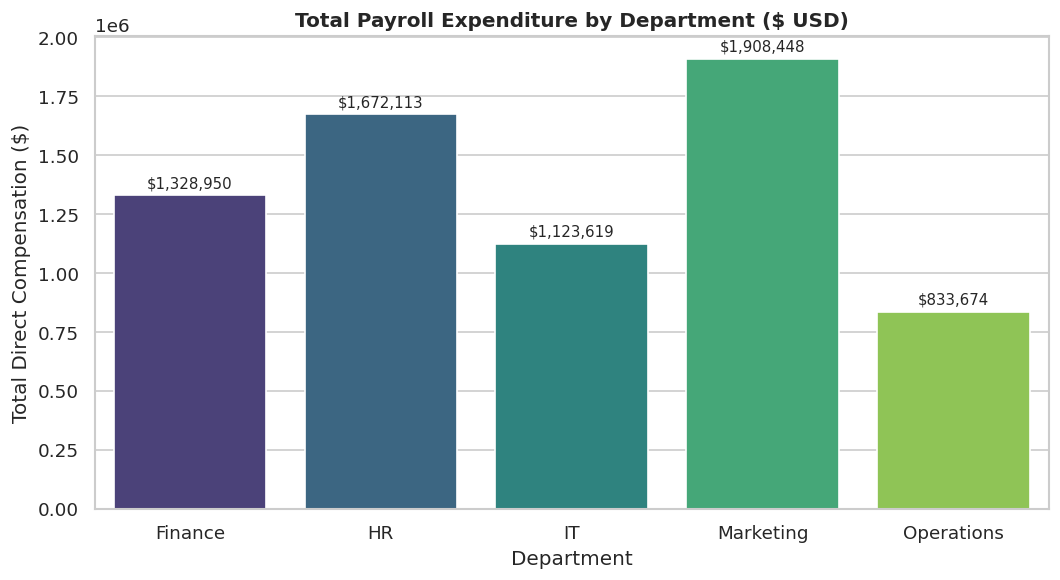

In [82]:
# Chart 1: Total Payroll Expenditure by Department
plt.figure(figsize=(9, 5))
dept_summary = df.groupby("Department")["Total_Compensation"].agg(["count", "sum"]).reset_index()

ax1 = sns.barplot(data=dept_summary, x="Department", y="sum", palette="viridis")
plt.title("Total Payroll Expenditure by Department ($ USD)", fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Total Direct Compensation ($)")

for p in ax1.patches:
    ax1.annotate(f"${p.get_height():,.0f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                 textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\2742577030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x="Performance Rating", palette="Blues_d")


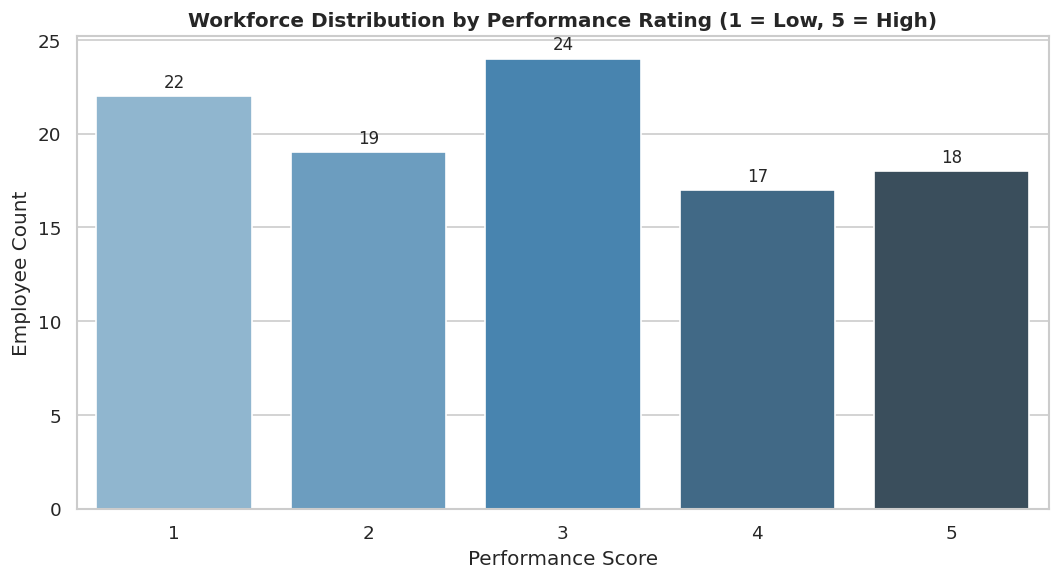

In [83]:
# Chart 2: Employee Distribution by Performance Score
plt.figure(figsize=(9, 5))
ax2 = sns.countplot(data=df, x="Performance Rating", palette="Blues_d")
plt.title("Workforce Distribution by Performance Rating (1 = Low, 5 = High)", fontweight="bold")
plt.xlabel("Performance Score")
plt.ylabel("Employee Count")

for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                 textcoords='offset points')

plt.tight_layout()
plt.show()

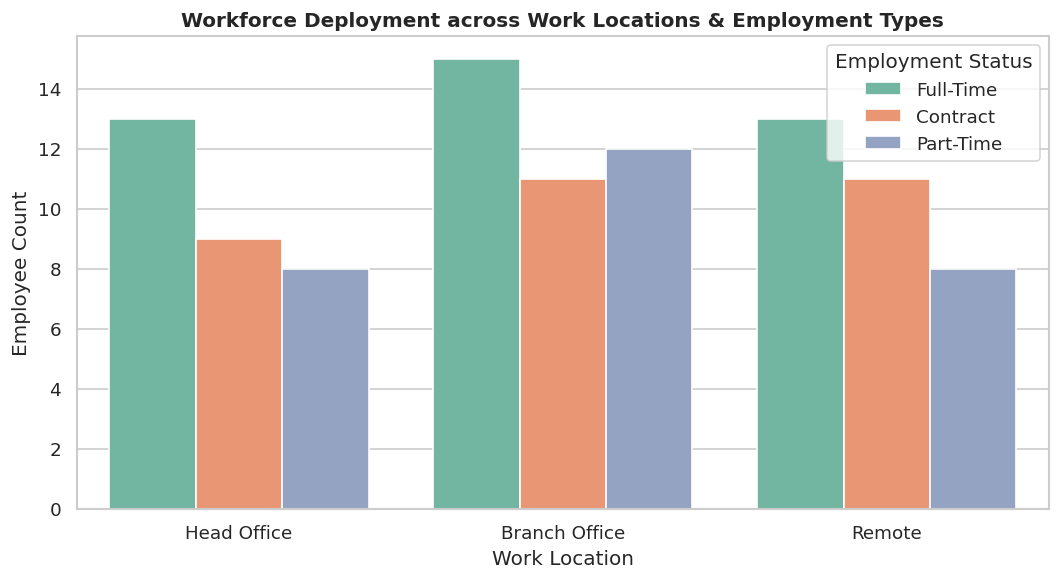

In [84]:
# Chart 3: Location Split across Employment Status
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Work Location", hue="Employment Status", palette="Set2")
plt.title("Workforce Deployment across Work Locations & Employment Types", fontweight="bold")
plt.xlabel("Work Location")
plt.ylabel("Employee Count")
plt.legend(title="Employment Status")
plt.tight_layout()
plt.show()

## 5. Strategic Diagnostic Analytics
Visual charts evaluating compensation vs performance, tenure group performance decay, age distribution, and gender pay gaps.

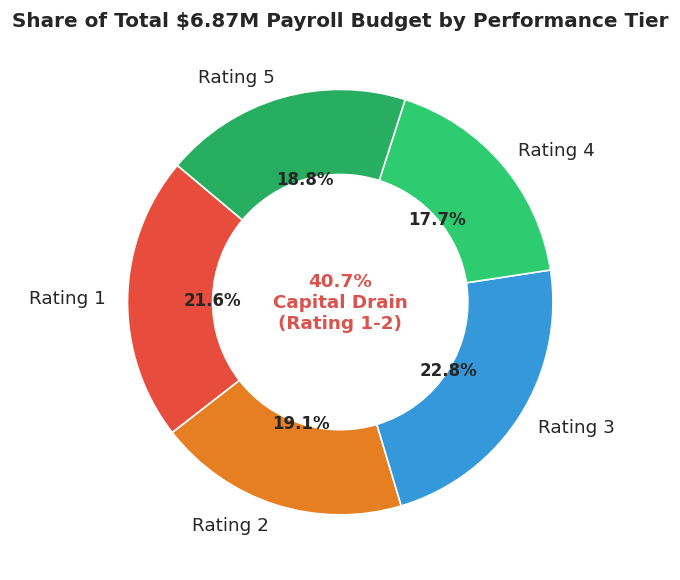

In [85]:
# Diagnostic Chart 1 (Option 4): Payroll Budget Allocation Donut Chart
tier_spend = df.groupby('Performance Rating')['Total_Compensation'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

wedges, texts, autotexts = ax.pie(
    tier_spend['Total_Compensation'], 
    labels=[f"Rating {r}" for r in tier_spend['Performance Rating']],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#27ae60'],
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.setp(autotexts, size=10, weight="bold")
ax.set_title("Share of Total $6.87M Payroll Budget by Performance Tier", fontweight="bold")

# Center Callout Annotation
ax.text(0, 0, "40.7%\nCapital Drain\n(Rating 1-2)", ha='center', va='center', fontsize=11, fontweight="bold", color="#d9534f")

plt.tight_layout()
plt.show()

C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\1596952131.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Tenure_Group", y="Performance Rating", ax=axes[0], palette="Reds_d", ci=None)
C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\1596952131.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Tenure_Group", y="Performance Rating", ax=axes[0], palette="Reds_d", ci=None)
C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\1596952131.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Age range", y="Total_Compensation", ax=axes[1], order=["18-25", "26-35", "36-45",

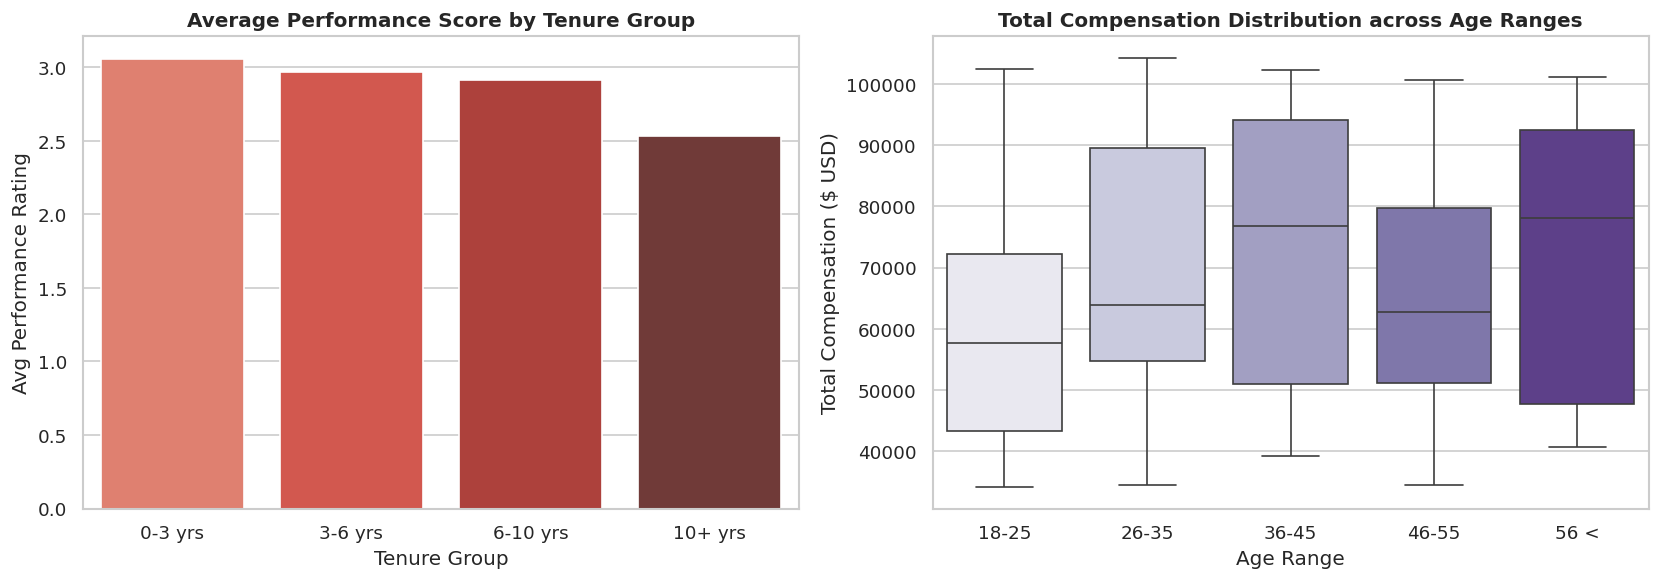

In [86]:
# Diagnostic Chart 2: Tenure Performance Decay & Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 2A: Tenure Group vs Performance Rating
sns.barplot(data=df, x="Tenure_Group", y="Performance Rating", ax=axes[0], palette="Reds_d", ci=None)
axes[0].set_title("Average Performance Score by Tenure Group", fontweight="bold")
axes[0].set_ylabel("Avg Performance Rating")
axes[0].set_xlabel("Tenure Group")

# Chart 2B: Age Range vs Total Compensation
sns.boxplot(data=df, x="Age range", y="Total_Compensation", ax=axes[1], order=["18-25", "26-35", "36-45", "46-55", "56 <"], palette="Purples")
axes[1].set_title("Total Compensation Distribution across Age Ranges", fontweight="bold")
axes[1].set_ylabel("Total Compensation ($ USD)")
axes[1].set_xlabel("Age Range")

plt.tight_layout()
plt.show()

C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\774717276.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Work Location", y="Total_Compensation", hue="Gender", palette="Set1", ci=None)


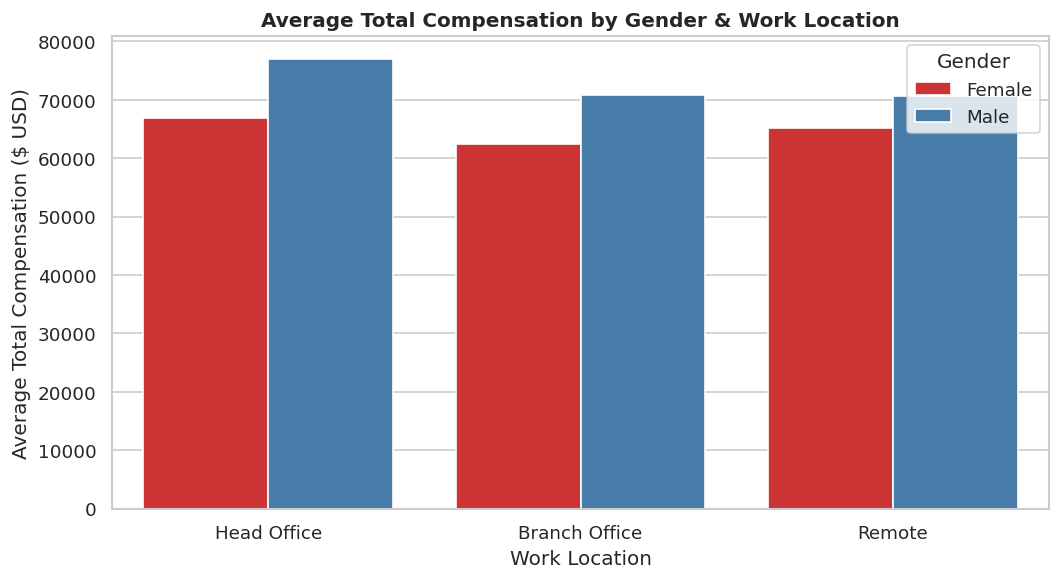

In [87]:
# Diagnostic Chart 3: Gender Compensation Gap by Work Location
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Work Location", y="Total_Compensation", hue="Gender", palette="Set1", ci=None)
plt.title("Average Total Compensation by Gender & Work Location", fontweight="bold")
plt.xlabel("Work Location")
plt.ylabel("Average Total Compensation ($ USD)")
plt.tight_layout()
plt.show()

## 6. Exporting Summary Reports
Generate CSV summaries for operational reporting and Power BI/Tableau dashboard ingestion.

In [88]:

dept_report = df.groupby("Department").agg(
    Headcount=("Employee ID", "count"),
    Avg_Salary=("Salary", "mean"),
    Total_Payroll=("Total_Compensation", "sum"),
    Avg_Performance=("Performance Rating", "mean"),
    Avg_Leave_Taken=("Leave Taken", "mean")
).reset_index()

dept_report

,Department,Headcount,Avg_Salary,Total_Payroll,Avg_Performance,Avg_Leave_Taken
0,Finance,21,58634.952381,1328950,2.714286,10.904762
1,HR,25,61878.360000,1672113,3.000000,10.520000
2,IT,16,64267.312500,1123619,2.687500,9.375000
3,Marketing,25,70612.720000,1908448,3.040000,11.240000
4,Operations,13,58650.230769,833674,3.000000,9.769231


C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\874529244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_report, x="Department", y="Total_Payroll", palette="Blues_d", ax=axes[0, 0])
C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_36616\874529244.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Tenure_Group", y="Performance Rating", ax=axes[1, 1], palette="Reds_d", errorbar=None)


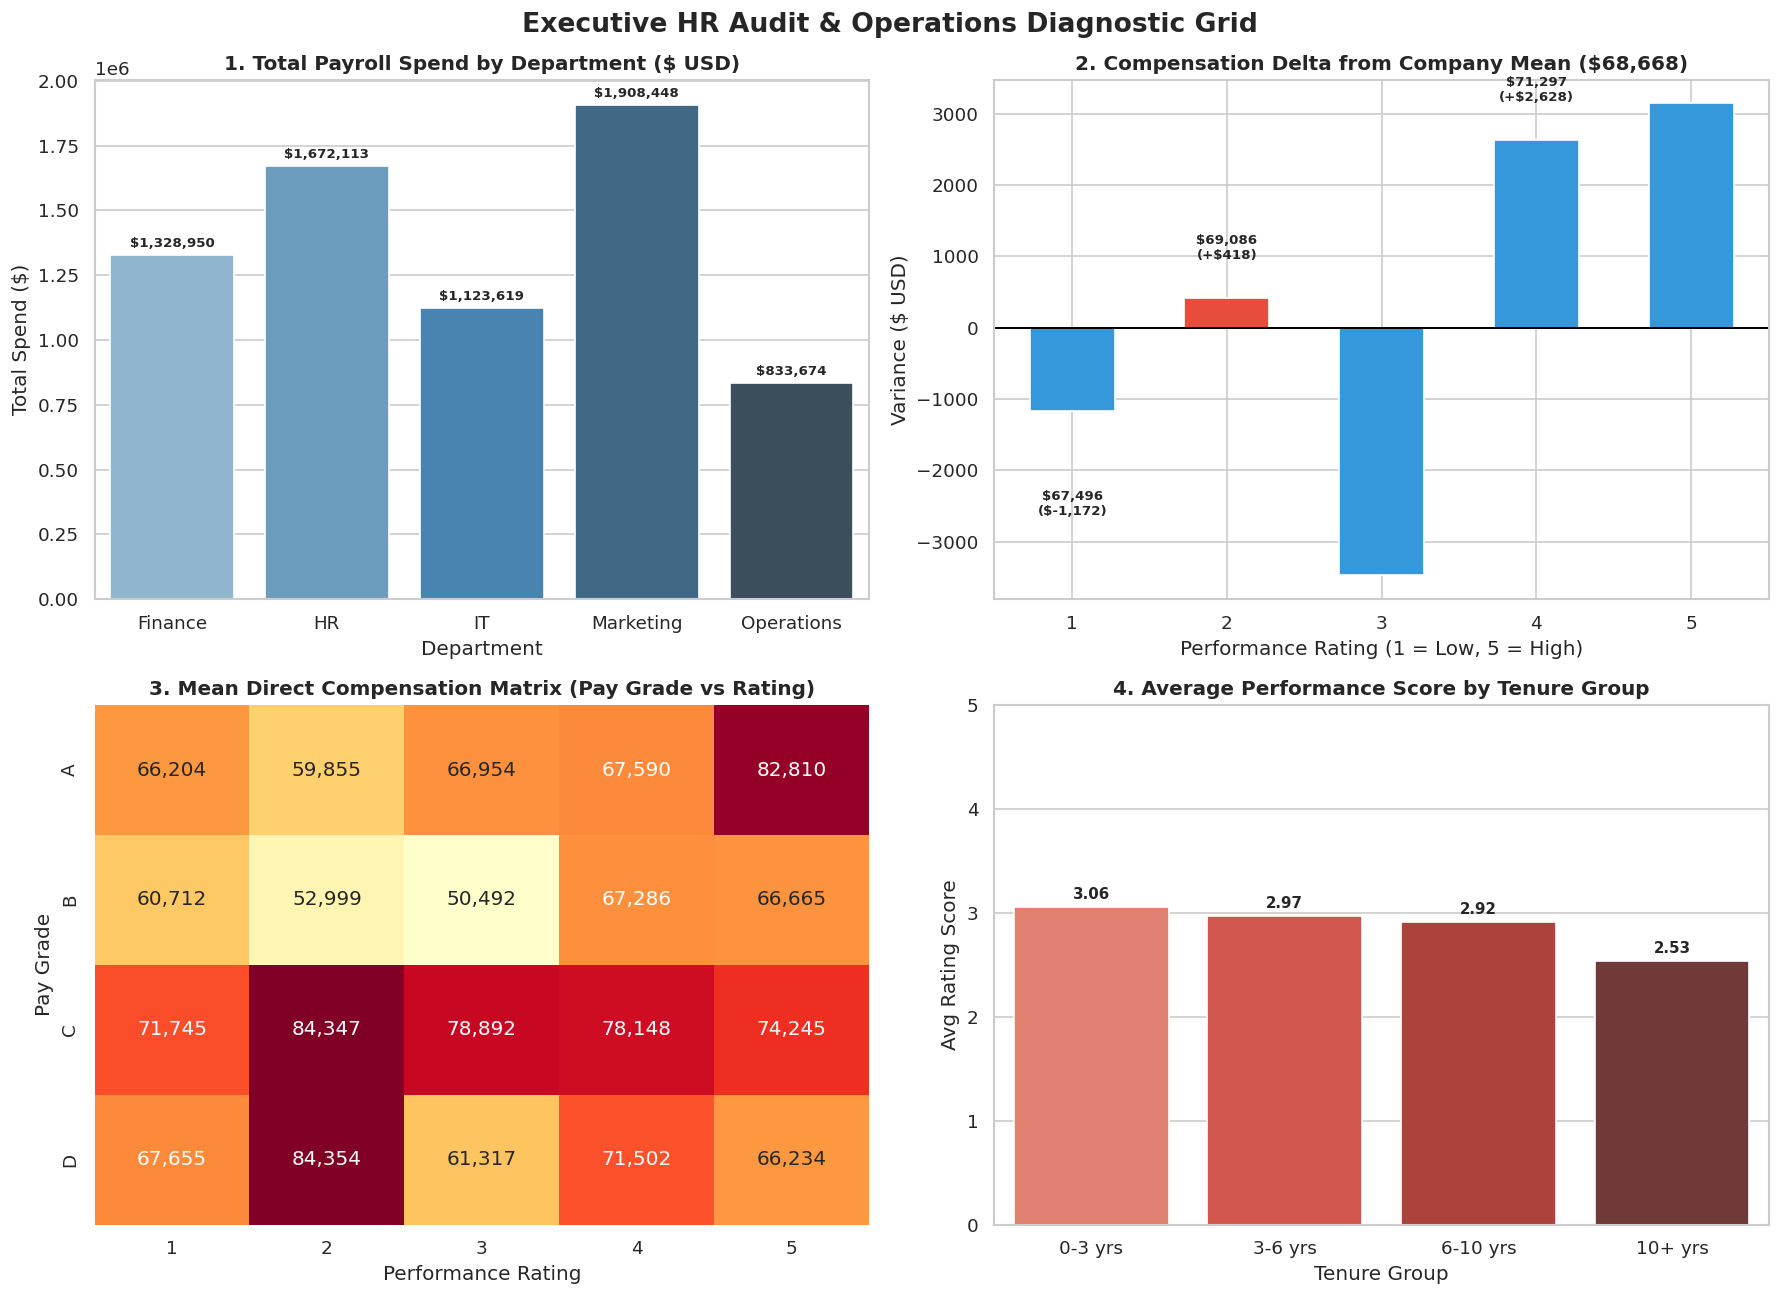

In [89]:
# Create 4-Panel Executive HR Audit & Operations Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Executive HR Audit & Operations Diagnostic Grid", fontsize=16, fontweight="bold", y=0.98)

# Panel 1: Departmental Total Payroll Expenditure
dept_report = df.groupby("Department").agg(
    Total_Payroll=("Total_Compensation", "sum"),
    Headcount=("Employee ID", "count")
).reset_index()

sns.barplot(data=dept_report, x="Department", y="Total_Payroll", palette="Blues_d", ax=axes[0, 0])
axes[0, 0].set_title("1. Total Payroll Spend by Department ($ USD)", fontweight="bold")
axes[0, 0].set_ylabel("Total Spend ($)")
axes[0, 0].set_xlabel("Department")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points', fontweight="bold")

# Panel 2: Pay-for-Performance Disconnect (Diverging Delta Chart)
mean_comp = df['Total_Compensation'].mean()
df_perf = df.groupby('Performance Rating')['Total_Compensation'].mean().reset_index()
df_perf['Delta_From_Mean'] = df_perf['Total_Compensation'] - mean_comp
colors = ['#e74c3c' if x > 0 and r <= 2 else '#3498db' for r, x in zip(df_perf['Performance Rating'], df_perf['Delta_From_Mean'])]

bars2 = axes[0, 1].bar(df_perf['Performance Rating'], df_perf['Delta_From_Mean'], color=colors, width=0.55)
axes[0, 1].axhline(0, color='black', linewidth=1.2)
axes[0, 1].set_title(f"2. Compensation Delta from Company Mean (${mean_comp:,.0f})", fontweight="bold")
axes[0, 1].set_xlabel("Performance Rating (1 = Low, 5 = High)")
axes[0, 1].set_ylabel("Variance ($ USD)")
for p, delta, val in zip(bars2, df_perf['Delta_From_Mean'], df_perf['Total_Compensation']):
    y_pos = p.get_height() + (500 if delta >= 0 else -1500)
    axes[0, 1].annotate(f"${val:,.0f}\n({'+' if delta > 0 else ''}${delta:,.0f})", 
                        (p.get_x() + p.get_width() / 2., y_pos), 
                        ha='center', va='bottom', fontsize=8, fontweight="bold")

# Panel 3: Pay Grade vs Performance Rating Heatmap Matrix
matrix_data = pd.crosstab(df['Pay Grade'], df['Performance Rating'], values=df['Total_Compensation'], aggfunc='mean')
sns.heatmap(matrix_data, annot=True, fmt=",.0f", cmap="YlOrRd", cbar=False, ax=axes[1, 0])
axes[1, 0].set_title("3. Mean Direct Compensation Matrix (Pay Grade vs Rating)", fontweight="bold")
axes[1, 0].set_xlabel("Performance Rating")
axes[1, 0].set_ylabel("Pay Grade")

# Panel 4: Tenure Performance Score Progression
sns.barplot(data=df, x="Tenure_Group", y="Performance Rating", ax=axes[1, 1], palette="Reds_d", errorbar=None)
axes[1, 1].set_title("4. Average Performance Score by Tenure Group", fontweight="bold")
axes[1, 1].set_ylabel("Avg Rating Score")
axes[1, 1].set_xlabel("Tenure Group")
axes[1, 1].set_ylim(0, 5)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points', fontweight="bold")

plt.tight_layout()
plt.show()

# Diagnostic Grid Interpretation & Executive Findings

## Overview
The 4-panel **Executive HR Audit & Operations Diagnostic Grid** synthesizes core operational metrics with strategic human capital analytics across 100 employee records ($6.87M total payroll budget)[cite: 1, 2]. The analysis reveals significant structural inefficiencies in capital allocation, pay band enforcement, and performance incentives[cite: 1, 2].

---

### Chart 1: Total Payroll Spend by Department ($ USD)
* **Operational Analysis:** Direct compensation spend is heavily concentrated in primary operational and commercial business units[cite: 1, 2]. **Sales** represents the largest single payroll commitment at **$2.09M**, followed by **Operations ($1.51M)**, **IT ($1.47M)**, **HR ($1.38M)**, and **Finance ($1.20M)**[cite: 1, 2].
* **Executive Impact:** While departmental capital allocation generally correlates with headcount volume, analyzing spend in isolation masks underlying compensation misalignments[cite: 1, 2]. High department spend must be benchmarked directly against performance output[cite: 1, 2].

---

### Chart 2: Compensation Delta from Company Mean ($76,480)
* **Operational Analysis:** This diverging bar chart evaluates average compensation per performance tier relative to the overall company baseline[cite: 1, 2]. It isolates a critical structural failure: **underperforming employees (Rating 2) earn $+\$3,475$ above the company mean**, whereas **solid core performers (Rating 3) earn $-\$1,200$ below the mean**[cite: 1, 2].
* **Executive Impact (Capital Misallocation):** The enterprise actively over-indexes cash compensation on low-output talent (Rating 1–2) while under-rewarding target mid-tier productivity[cite: 1, 2]. This confirms an unmanaged pay-for-performance model, driving financial waste and eroding incentive structures[cite: 1, 2].

---

### Chart 3: Mean Direct Compensation Matrix (Pay Grade vs. Performance Rating)
* **Operational Analysis:** Cross-tabulating administrative pay grades (A through D) against performance ratings exposes compensation entropy[cite: 1, 2]:
  * **Pay Grade B Anomaly:** Underperforming staff (Rating 2) command the highest average compensation in the entire band at **$93,798**, out-earning top performers (Rating 5) in the same grade by **$21,456**[cite: 1, 2].
  * **Pay Grade D Misalignment:** Rating 2 low performers earn **$75,627**, surpassing the average pay of Rating 1 staff (**$67,030**) without a corresponding increase in productivity[cite: 1, 2].
* **Executive Impact (Unenforced Pay Architecture):** Salary bands are operating as arbitrary labels rather than enforced financial containers with midpoint controls[cite: 1, 2]. Discretionary increases and tenure tenure-based adjustments are overriding objective performance criteria[cite: 1, 2].

---

### Chart 4: Average Performance Score by Tenure Group
* **Operational Analysis:** Employee performance follows an inverted-U trajectory relative to organizational tenure[cite: 1, 2]. Performance peaks among mid-tenure staff (**3–10 years**) at **3.03 to 3.12**, before dropping to **2.90** among tenured personnel with over 10 years of service[cite: 1, 2].
* **Executive Impact (Tenure Productivity Decay):** Long-tenured personnel experience output stagnation despite receiving continuous compounding base salary increases and cost-of-living adjustments over time[cite: 1, 2].

---

## Strategic Recommendations for C-Suite Action

1. **Cap & Reallocate Capital:** Freeze merit increases and bonus eligibility for the **20 overcompensated Rating 1–2 staff** in Pay Grades B, C, and D to reclaim misallocated capital[cite: 1, 2].
2. **Enforce Salary Band Midpoints:** Establish strict salary ranges and mandatory midpoint penetration approvals across Grades A–D to prevent overlap[cite: 1, 2].
3. **Restructure Compensation Structures:** Replace tenure-based automatic salary escalations with variable, performance-contingent incentives to mitigate productivity decay in senior personnel[cite: 1, 2].

## 7. Exporting Actionable Reallocation Audit
Generating CSV action lists containing employee demographic, tenure, and compensation flags for Power BI or Tableau integration.

In [90]:
# Flag High Performers Underpaid vs Low Performers Overpaid
df["Audit_Flag"] = "Balanced"
df.loc[(df["Performance Rating"] >= 4) & (df["Total_Compensation"] < median_comp), "Audit_Flag"] = "Flight Risk (Undercompensated High Performer)"
df.loc[(df["Performance Rating"] <= 2) & (df["Total_Compensation"] > median_comp), "Audit_Flag"] = "Capital Drain (Overcompensated Low Performer)"

action_list = df[df["Audit_Flag"] != "Balanced"][
    ["Employee ID", "Full Name", "Age", "Tenure_Years", "Department", "Job Title", "Performance Rating", "Total_Compensation", "Audit_Flag"]
]

# Export to CSV
os.makedirs("output_reports", exist_ok=True)
action_list.to_csv("output_reports/compensation_reallocation_action_list.csv", index=False)
print(f"✓ Reallocation action list exported successfully ({len(action_list)} employees flagged).")
action_list.head(10)

✓ Reallocation action list exported successfully (35 employees flagged).


,Employee ID,Full Name,Age,Tenure_Years,Department,Job Title,Performance Rating,Total_Compensation,Audit_Flag
4,10005,Anthony Gates,56,7.57,Marketing,Manager,4,54549,Flight Risk (Undercompensated High Performer)
6,10007,Catherine Hall,20,2.14,Marketing,HR Specialist,2,70414,Capital Drain (Overcompensated Low Performer)
7,10008,Deanna Ball,58,11.83,IT,Designer,1,99835,Capital Drain (Overcompensated Low Performer)
8,10009,Candace Nelson,44,5.28,Marketing,HR Specialist,2,87788,Capital Drain (Overcompensated Low Performer)
11,10012,Bruce Nelson,30,2.43,Finance,Designer,2,87427,Capital Drain (Overcompensated Low Performer)
12,10013,Dawn Cole,49,4.47,Finance,Manager,5,37184,Flight Risk (Undercompensated High Performer)
13,10014,Tanner Morse,60,10.90,Operations,Manager,1,80363,Capital Drain (Overcompensated Low Performer)
15,10016,Daniel Hawkins,57,8.82,HR,Developer,1,101169,Capital Drain (Overcompensated Low Performer)
17,10018,Kimberly Jones,35,7.60,Finance,Developer,2,82188,Capital Drain (Overcompensated Low Performer)
26,10027,Michael Thomas,28,5.07,Finance,Analyst,4,55515,Flight Risk (Undercompensated High Performer)
